<a href="https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/master/notebooks/fluidflow/flixiblepipes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Flexible multiphase flowlines and risers with NeqSim

This notebook develops an engineering workflow for multiphase pressure drop, liquid
holdup, thermal behavior, and velocity screening in flexible subsea flowlines and risers.
It preserves the original methane–heptane–water pipeline example and expands it into a
connected four-leg lazy-wave riser application using the current `PipeBeggsAndBrills`
API.

**Intended audience:** subsea, pipeline, process, and flow-assurance engineers; graduate
students; and Python users with basic multiphase-flow knowledge.

## Prerequisites and learning objectives

You should understand pressure, elevation, superficial velocity, liquid holdup, heat
transfer, and the distinction between hydraulic and structural design.

After completing the notebook, you can:

1. build a three-phase wellstream with current NeqSim thermodynamics;
2. reproduce and validate the original 100 km Beggs–Brill example;
3. retrieve pressure, holdup, velocity, temperature, and flow-regime profiles;
4. compare adiabatic, specified-U, and detailed-insulation thermal models;
5. connect flowline, sag, arch, and topside-riser legs without hidden state;
6. verify pressure recovery in a descending section and hydrostatic loss in rising legs;
7. screen mixture velocity against NeqSim's API RP 14E result;
8. vary internal diameter and rate; and
9. select a feasible hydraulic design while documenting structural limitations.

## 2. Reproducible NeqSim `master` source build

The released Python package is used only as the JPype bridge. The runtime clones current `equinor/neqsim` `master`, builds its Java JAR, records the resolved commit and JAR hash, and verifies a main-only class was loaded from that JAR before any simulation starts. A clean local validation may supply `NEQSIM_SOURCE_ROOT` and `NEQSIM_SOURCE_JAR` for the same checked-out commit.


In [1]:
from importlib.metadata import PackageNotFoundError, version
from pathlib import Path
import hashlib
import importlib.util
import os
import platform
import subprocess
import sys

PYTHON_NEQSIM_VERSION = "3.16.0"
NEQSIM_SOURCE_REF = "master"
NEQSIM_SOURCE_REPOSITORY = "https://github.com/equinor/neqsim.git"
SOURCE_ROOT = Path(
    os.environ.get("NEQSIM_SOURCE_ROOT", "/content/neqsim-main")
).resolve()
SOURCE_JAR_OVERRIDE = os.environ.get("NEQSIM_SOURCE_JAR")

try:
    installed_bridge_version = version("neqsim")
except PackageNotFoundError:
    installed_bridge_version = None
if installed_bridge_version != PYTHON_NEQSIM_VERSION:
    subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "--quiet",
            "--no-cache-dir",
            f"neqsim=={PYTHON_NEQSIM_VERSION}",
        ],
        check=True,
    )

using_local_source = "NEQSIM_SOURCE_ROOT" in os.environ
if not (SOURCE_ROOT / ".git").is_dir():
    subprocess.run(
        [
            "git",
            "clone",
            "--quiet",
            "--depth",
            "1",
            "--branch",
            NEQSIM_SOURCE_REF,
            NEQSIM_SOURCE_REPOSITORY,
            str(SOURCE_ROOT),
        ],
        check=True,
    )
elif not using_local_source:
    subprocess.run(
        [
            "git",
            "-C",
            str(SOURCE_ROOT),
            "fetch",
            "--quiet",
            "--depth",
            "1",
            "origin",
            NEQSIM_SOURCE_REF,
        ],
        check=True,
    )
    subprocess.run(
        [
            "git",
            "-C",
            str(SOURCE_ROOT),
            "checkout",
            "--quiet",
            "--detach",
            "FETCH_HEAD",
        ],
        check=True,
    )

# Record the immutable commit selected from current master (git rev-parse HEAD).
NEQSIM_SOURCE_COMMIT = subprocess.check_output(
    ["git", "-C", str(SOURCE_ROOT), "rev-parse", "HEAD"],
    text=True,
).strip()

if SOURCE_JAR_OVERRIDE:
    SOURCE_JAR = Path(SOURCE_JAR_OVERRIDE).resolve()
else:
    jar_candidates = [
        path
        for path in (SOURCE_ROOT / "target").glob("neqsim-*.jar")
        if not any(
            marker in path.name
            for marker in ("sources", "javadoc", "tests", "original")
        )
    ]
    if not jar_candidates:
        subprocess.run(
            [
                str(SOURCE_ROOT / "mvnw"),
                "-q",
                "-DskipTests",
                "-Dmaven.javadoc.skip=true",
                "package",
            ],
            cwd=SOURCE_ROOT,
            check=True,
        )
        jar_candidates = [
            path
            for path in (SOURCE_ROOT / "target").glob("neqsim-*.jar")
            if not any(
                marker in path.name
                for marker in ("sources", "javadoc", "tests", "original")
            )
        ]
    if not jar_candidates:
        raise FileNotFoundError(
            "The NeqSim master source build did not produce a runtime JAR."
        )
    SOURCE_JAR = sorted(jar_candidates, key=lambda path: len(path.name))[0]

SOURCE_JAR_SHA256 = hashlib.sha256(SOURCE_JAR.read_bytes()).hexdigest()
os.environ["NEQSIM_JVM_AUTOSTART"] = "0"
os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")

import jpype

if jpype.isJVMStarted():
    raise RuntimeError(
        "The JVM started before the NeqSim master JAR was selected. "
        "Restart the runtime and run all cells."
    )
jpype.addClassPath(str(SOURCE_JAR))
from neqsim.neqsimpython import init_jvm

init_jvm()
SOURCE_PROBE = jpype.JClass(
    "neqsim.process.engineering.design.EngineeringDesignLoop"
)
LOADED_JAR_LOCATION = str(
    SOURCE_PROBE.class_.getProtectionDomain().getCodeSource().getLocation()
)
assert SOURCE_JAR.name in LOADED_JAR_LOCATION

print(f"NeqSim Python bridge: {version('neqsim')}")
print(f"NeqSim source ref: {NEQSIM_SOURCE_REF}")
print(f"NeqSim source commit: {NEQSIM_SOURCE_COMMIT}")
print(f"NeqSim source JAR SHA-256: {SOURCE_JAR_SHA256}")
print(f"Loaded Java classes from: {LOADED_JAR_LOCATION}")
print(f"Python runtime: {platform.python_version()}")


NeqSim Python bridge: 3.16.0
NeqSim source ref: master
NeqSim source commit: 13a6f31ee4ce3d5394291edc2179ffb6993eb130
NeqSim source JAR SHA-256: ee992a648f93835feca4bfb4a2b6cb0f356afe4f89282259b3b4048f32310da3
Loaded Java classes from: file:/workspace/scratch/ab308ea4a4a5/neqsim-main-build/target/neqsim-3.16.0.jar
Python runtime: 3.12.13


In [2]:
import importlib.metadata
import math
import platform

from IPython.display import YouTubeVideo, display
import jpype
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch
import numpy as np
import pandas as pd

from neqsim import jneqsim
from neqsim.thermo import fluid

NEQSIM_VERSION = importlib.metadata.version("neqsim")
PYTHON_VERSION = platform.python_version()
JAVA_SYSTEM = jpype.JClass("java.lang.System")
JAVA_VERSION = JAVA_SYSTEM.getProperty("java.version")

plt.style.use("seaborn-v0_8-whitegrid")
COLORS = {
    "blue": "#0072B2",
    "orange": "#E69F00",
    "green": "#009E73",
    "red": "#D55E00",
    "purple": "#CC79A7",
    "grey": "#5F6368",
    "yellow": "#F0E442",
}

print(f"NeqSim Python bridge: {NEQSIM_VERSION}")
print(f"NeqSim source commit: {NEQSIM_SOURCE_COMMIT}")
print(f"Loaded Java classes from: {LOADED_JAR_LOCATION}")
print(f"Python version: {PYTHON_VERSION}")
print(f"Java version: {JAVA_VERSION}")

NeqSim Python bridge: 3.16.0
NeqSim source commit: 13a6f31ee4ce3d5394291edc2179ffb6993eb130
Loaded Java classes from: file:/workspace/scratch/ab308ea4a4a5/neqsim-main-build/target/neqsim-3.16.0.jar
Python version: 3.12.13
Java version: 17.0.19


## 2. Preserved introductory visual

The original notebook embedded the following public lecture video as its introductory
visual. It is retained with its original YouTube identifier and distinguished from the
NeqSim-calculated figures that follow.

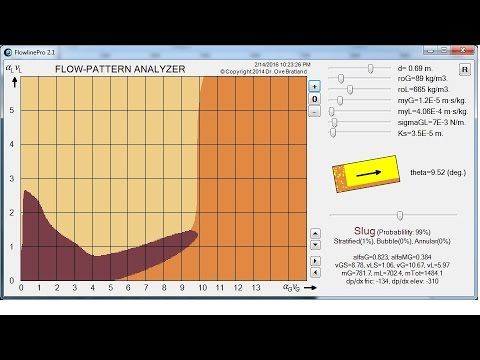

In [3]:
display(
    YouTubeVideo(
        "7Tsomarcq30",
        width=600,
        height=400,
    )
)

## 3. Engineering theory

Beggs–Brill represents total pressure change as friction, hydrostatic, and acceleration
contributions:

$$
\Delta p_{\mathrm{total}} = \Delta p_{\mathrm{friction}} + \rho_m g \Delta z + \Delta p_{\mathrm{acceleration}}
$$

Here $\Delta p$ is pressure change in Pa, $\rho_m$ is mixture density in kg/m³, $g$ is
gravitational acceleration in m/s², and $\Delta z$ is outlet-minus-inlet elevation in m.
A descending leg can therefore have a negative net pressure drop when hydrostatic
recovery exceeds friction.

Superficial phase velocity is the phase volumetric flow divided by the full pipe area.
The no-slip input liquid fraction is

$$
\lambda_L = \frac{v_{sL}}{v_{sL} + v_{sG}}
$$

Beggs–Brill calculates actual liquid holdup $H_L$ from $\lambda_L$, Froude number,
inclination, and the predicted flow regime. Holdup controls hydrostatic head and liquid
inventory, so it is not interchangeable with inlet liquid fraction.

For a constant environmental temperature and effective overall heat-transfer coefficient,
the analytical NTU form is

$$
T_{\mathrm{out}} = T_{\mathrm{env}} + (T_{\mathrm{in}} - T_{\mathrm{env}})\exp(-UA/\dot{m}c_p)
$$

where $U$ is W/(m²·K), $A$ is external heat-transfer area in m², $\dot{m}$ is kg/s, and
$c_p$ is J/(kg·K). NeqSim can use a specified $U$ or calculate a detailed resistance from
inner convection, pipe wall, insulation, and outer convection.

### Validity limits

Beggs–Brill is an empirical steady-state correlation. It does not resolve transient
severe slugging, individual slug arrival, flexible-pipe structural layers, curvature,
collapse, ovalization, fatigue, armor stress, vortex-induced vibration, upheaval
buckling, or installation loads. The lazy-wave geometry is represented by connected
straight hydraulic legs. Detailed flexible-pipe integrity must follow qualified vendor
methods and applicable standards such as API 17J/17B and DNV-ST-F119.

## 4. Design basis and original-example preservation

The original example used methane, n-heptane, and water in the ratio 0.80:0.10:0.01 at
100 bara, 50.15 °C, and 20 MSm³/day through a 100 km, 0.710 m pipeline. The old amounts
summed to 0.91; they are normalized explicitly here without changing their relative
proportions. The original inlet/outlet state comparison, flow regime, pressure drop, and
superficial-velocity intent are all retained.

In [4]:
RAW_COMPOSITION = {
    "methane": 0.80,
    "n-heptane": 0.10,
    "water": 0.01,
}
composition_total = sum(RAW_COMPOSITION.values())
COMPOSITION = {
    component: amount / composition_total
    for component, amount in RAW_COMPOSITION.items()
}

ORIGINAL_PRESSURE_BARA = 100.0
ORIGINAL_TEMPERATURE_C = 50.15
ORIGINAL_FLOW_MSM3_DAY = 20.0
ORIGINAL_LENGTH_M = 100000.0
ORIGINAL_DIAMETER_M = 0.710
LINER_ROUGHNESS_M = 5.0e-6

print(f"Normalized composition sum: {sum(COMPOSITION.values()):.12f}")
display(
    pd.DataFrame(
        {
            "component": list(COMPOSITION),
            "mole_fraction": list(COMPOSITION.values()),
        }
    )
)

Normalized composition sum: 1.000000000000


,component,mole_fraction
0,methane,0.879121
1,n-heptane,0.109890
2,water,0.010989


In [5]:
def create_wellstream(
    pressure_bara=ORIGINAL_PRESSURE_BARA,
    temperature_c=ORIGINAL_TEMPERATURE_C,
    flow_msm3_day=ORIGINAL_FLOW_MSM3_DAY,
    name="wellstream",
):
    system = fluid("srk")

    for component, mole_fraction in COMPOSITION.items():
        system.addComponent(component, mole_fraction)

    system.setMixingRule("classic")
    system.setMultiPhaseCheck(True)
    system.setPressure(pressure_bara, "bara")
    system.setTemperature(temperature_c, "C")

    stream_class = jneqsim.process.equipment.stream.Stream
    inlet = stream_class(name, system)
    inlet.setFlowRate(flow_msm3_day, "MSm3/day")
    inlet.setPressure(pressure_bara, "bara")
    inlet.setTemperature(temperature_c, "C")
    inlet.run()
    return inlet

In [6]:
original_feed = create_wellstream()
feed_system = original_feed.getThermoSystem()
feed_system.initPhysicalProperties()

feed_report = pd.DataFrame(
    {
        "quantity": [
            "Pressure",
            "Temperature",
            "Standard gas-equivalent flow",
            "Mass flow",
            "Number of phases",
            "Overall molar mass",
        ],
        "value": [
            original_feed.getPressure("bara"),
            original_feed.getTemperature("C"),
            original_feed.getFlowRate("MSm3/day"),
            original_feed.getFlowRate("kg/sec"),
            feed_system.getNumberOfPhases(),
            feed_system.getMolarMass() * 1000.0,
        ],
        "unit": [
            "bara",
            "°C",
            "MSm³/day",
            "kg/s",
            "–",
            "kg/kmol",
        ],
    }
)
display(feed_report)

,quantity,value,unit
0,Pressure,100.000000,bara
1,Temperature,50.150000,°C
2,Standard gas-equivalent flow,20.000000,MSm³/day
3,Mass flow,247.815149,kg/s
4,Number of phases,3.000000,–
5,Overall molar mass,25.313242,kg/kmol


NeqSim flashes the stream before it enters the pipe. The SRK model is retained to preserve
the original example and because the purpose is API and correlation teaching, not
high-accuracy aqueous-phase thermodynamics. Model and composition sensitivity should be
revisited for project work.

In [7]:
def configure_pipe(
    name,
    inlet_stream,
    length_m,
    diameter_m,
    elevation_m,
    increments,
    thermal_mode="adiabatic",
    specified_u_w_m2_k=4.0,
):
    pipe_class = jneqsim.process.equipment.pipeline.PipeBeggsAndBrills
    pipeline = pipe_class(name, inlet_stream)
    pipeline.setLength(length_m)
    pipeline.setDiameter(diameter_m)
    pipeline.setElevation(elevation_m)
    pipeline.setAngle(
        math.degrees(math.asin(elevation_m / length_m))
    )
    pipeline.setPipeWallRoughness(LINER_ROUGHNESS_M)
    pipeline.setNumberOfIncrements(increments)

    if thermal_mode == "specified":
        pipeline.setConstantSurfaceTemperature(5.0, "C")
        pipeline.setHeatTransferCoefficient(specified_u_w_m2_k)
        pipeline.setIncludeJouleThomsonEffect(True)
        pipeline.setIncludeFrictionHeating(True)
    elif thermal_mode == "detailed":
        heat_mode = pipe_class.HeatTransferMode.DETAILED_U
        pipeline.setConstantSurfaceTemperature(5.0, "C")
        pipeline.setOuterHeatTransferCoefficient(500.0)
        pipeline.setPipeWallThermalConductivity(45.0)
        pipeline.setInsulation(0.05, 0.04)
        pipeline.setHeatTransferMode(heat_mode)
        pipeline.setIncludeJouleThomsonEffect(True)
        pipeline.setIncludeFrictionHeating(True)

    pipeline.run()
    return pipeline

## 5. Preserved example — 100 km multiphase pipeline

Forty hydraulic increments replace the original five to provide a more useful profile.
The pipeline remains horizontal and adiabatic, so the change is numerical resolution
rather than a new physical assumption.

In [8]:
original_pipeline = configure_pipe(
    name="original 100 km multiphase pipeline",
    inlet_stream=original_feed,
    length_m=ORIGINAL_LENGTH_M,
    diameter_m=ORIGINAL_DIAMETER_M,
    elevation_m=0.0,
    increments=40,
    thermal_mode="adiabatic",
)

original_pressure_bar = np.asarray(
    original_pipeline.getPressureProfile(),
    dtype=float,
)
original_holdup = np.asarray(
    original_pipeline.getLiquidHoldupProfile(),
    dtype=float,
)
original_gas_velocity_m_s = np.asarray(
    list(original_pipeline.getGasSuperficialVelocityProfile()),
    dtype=float,
)
original_liquid_velocity_m_s = np.asarray(
    list(original_pipeline.getLiquidSuperficialVelocityProfile()),
    dtype=float,
)
original_distance_km = np.asarray(
    list(original_pipeline.getLengthProfile()),
    dtype=float,
) / 1000.0

original_summary = pd.DataFrame(
    {
        "quantity": [
            "Flow regime",
            "Total pressure drop",
            "Outlet pressure",
            "Inlet superficial velocity",
            "Outlet superficial velocity",
            "Minimum liquid holdup",
            "Maximum liquid holdup",
        ],
        "value": [
            original_pipeline.getFlowRegime(),
            original_pipeline.getPressureDrop(),
            original_pipeline.getOutStream().getPressure("bara"),
            original_pipeline.getInletSuperficialVelocity(),
            original_pipeline.getOutletSuperficialVelocity(),
            original_holdup.min(),
            original_holdup.max(),
        ],
        "unit": ["–", "bar", "bara", "m/s", "m/s", "–", "–"],
    }
)
display(original_summary)

,quantity,value,unit
0,Flow regime,"(I, N, T, E, R, M, I, T, T, E, N, T)",–
1,Total pressure drop,36.141459,bar
2,Outlet pressure,63.858541,bara
3,Inlet superficial velocity,5.39332,m/s
4,Outlet superficial velocity,8.645676,m/s
5,Minimum liquid holdup,0.163126,–
6,Maximum liquid holdup,0.221423,–


In [9]:
def phase_state_table(label, process_stream):
    system = process_stream.getThermoSystem()
    system.initPhysicalProperties()
    records = []

    for phase_index in range(system.getNumberOfPhases()):
        phase = system.getPhase(phase_index)
        records.append(
            {
                "state": label,
                "phase": str(phase.getPhaseTypeName()),
                "phase_fraction_mol": system.getBeta(phase_index),
                "density_kg_m3": phase.getDensity("kg/m3"),
                "viscosity_Pa_s": phase.getViscosity("kg/msec"),
            }
        )

    return records


state_records = []
state_records.extend(
    phase_state_table("Inlet", original_feed)
)
state_records.extend(
    phase_state_table(
        "Outlet",
        original_pipeline.getOutStream(),
    )
)
inlet_outlet_phase_table = pd.DataFrame(state_records)
display(inlet_outlet_phase_table.round(6))

,state,phase,phase_fraction_mol,density_kg_m3,viscosity_Pa_s
0,Inlet,gas,0.832657,71.261177,0.000014
1,Inlet,oil,0.157789,590.127659,0.000193
2,Inlet,aqueous,0.009554,979.882411,0.000546
3,Outlet,gas,0.855339,43.430064,0.000013
4,Outlet,oil,0.135573,620.130475,0.000240
5,Outlet,aqueous,0.009088,979.017532,0.000544


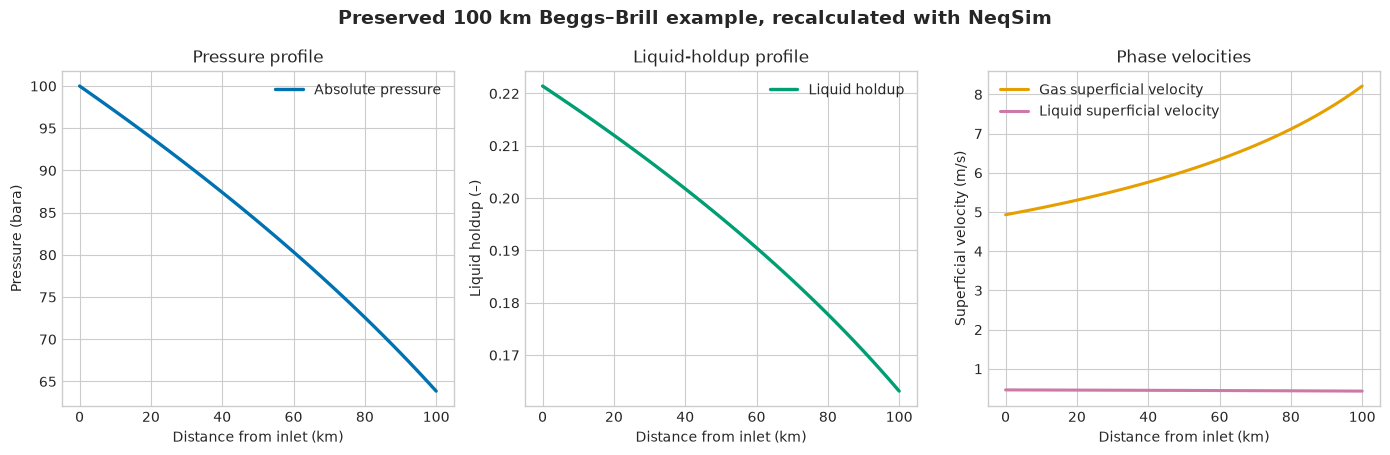

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(14.0, 4.6))

axes[0].plot(
    original_distance_km,
    original_pressure_bar,
    color=COLORS["blue"],
    linewidth=2.4,
    label="Absolute pressure",
)
axes[0].set_xlabel("Distance from inlet (km)")
axes[0].set_ylabel("Pressure (bara)")
axes[0].set_title("Pressure profile")
axes[0].legend(loc="best")

axes[1].plot(
    original_distance_km,
    original_holdup,
    color=COLORS["green"],
    linewidth=2.4,
    label="Liquid holdup",
)
axes[1].set_xlabel("Distance from inlet (km)")
axes[1].set_ylabel("Liquid holdup (–)")
axes[1].set_title("Liquid-holdup profile")
axes[1].legend(loc="best")

axes[2].plot(
    original_distance_km,
    original_gas_velocity_m_s,
    color=COLORS["orange"],
    linewidth=2.2,
    label="Gas superficial velocity",
)
axes[2].plot(
    original_distance_km,
    original_liquid_velocity_m_s,
    color=COLORS["purple"],
    linewidth=2.2,
    label="Liquid superficial velocity",
)
axes[2].set_xlabel("Distance from inlet (km)")
axes[2].set_ylabel("Superficial velocity (m/s)")
axes[2].set_title("Phase velocities")
axes[2].legend(loc="best")

fig.suptitle(
    "Preserved 100 km Beggs–Brill example, recalculated with NeqSim",
    fontsize=14,
    weight="bold",
)
fig.tight_layout()
plt.show()

**Numerical refresh.** The old NeqSim 2.5.35 output printed a 9.707 bar pressure drop while
its stored outlet pressure of 59.829 bara implied about 40.171 bar. In NeqSim 3.16.0,
`getPressureDrop()` and the complete pressure profile agree: the recalculated total drop
is 36.141 bar and the outlet is 63.859 bara. The current result is therefore internally
consistent and replaces the stale ambiguous number.

## 6. Thermal capability — insulation and seawater cooling

Flexible-pipe thermal layers strongly affect hydrate and wax margin. Three 10 km,
0.30 m flowline cases compare adiabatic behavior, a specified effective U-value of
4 W/(m²·K), and NeqSim's detailed resistance model with 50 mm insulation at
0.04 W/(m·K), steel conductivity 45 W/(m·K), and seawater convection
500 W/(m²·K).

In [11]:
thermal_modes = [
    ("Adiabatic", "adiabatic"),
    ("Specified U = 4 W/(m²·K)", "specified"),
    ("Detailed 50 mm insulation", "detailed"),
]
thermal_results = []
thermal_profiles = {}

for label, mode in thermal_modes:
    thermal_feed = create_wellstream(
        flow_msm3_day=3.0,
        name=f"thermal feed {label}",
    )
    thermal_pipe = configure_pipe(
        name=f"thermal case {label}",
        inlet_stream=thermal_feed,
        length_m=10000.0,
        diameter_m=0.30,
        elevation_m=0.0,
        increments=40,
        thermal_mode=mode,
    )
    temperature_profile_c = np.asarray(
        thermal_pipe.getTemperatureProfile(),
        dtype=float,
    ) - 273.15
    if temperature_profile_c.size == 1:
        temperature_profile_c = np.full(
            41,
            temperature_profile_c.item(),
        )
    thermal_profiles[label] = temperature_profile_c
    thermal_results.append(
        {
            "case": label,
            "effective_U_W_m2_K": (
                thermal_pipe.getHeatTransferCoefficient()
            ),
            "outlet_temperature_C": (
                thermal_pipe.getOutStream().getTemperature("C")
            ),
            "pressure_drop_bar": thermal_pipe.getPressureDrop(),
        }
    )

thermal_table = pd.DataFrame(thermal_results)
display(thermal_table.round(4))

,case,effective_U_W_m2_K,outlet_temperature_C,pressure_drop_bar
0,Adiabatic,0.0000,50.1500,5.9211
1,Specified U = 4 W/(m²·K),4.0000,37.1123,5.7485
2,Detailed 50 mm insulation,0.9417,46.7801,5.8783


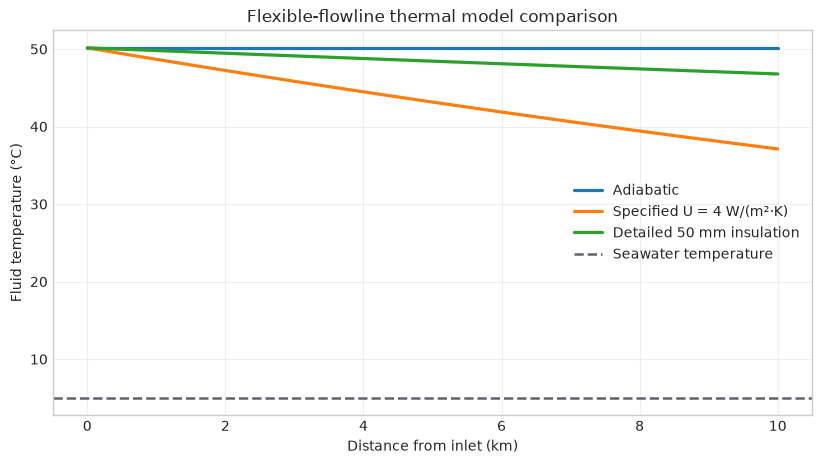

In [12]:
thermal_distance_km = np.linspace(0.0, 10.0, 41)
fig, ax = plt.subplots(figsize=(9.8, 5.0))

for label, profile in thermal_profiles.items():
    ax.plot(
        thermal_distance_km,
        profile,
        linewidth=2.3,
        label=label,
    )

ax.axhline(
    5.0,
    color=COLORS["grey"],
    linestyle="--",
    linewidth=1.8,
    label="Seawater temperature",
)
ax.set_xlabel("Distance from inlet (km)")
ax.set_ylabel("Fluid temperature (°C)")
ax.set_title("Flexible-flowline thermal model comparison")
ax.legend(loc="best")
ax.grid(alpha=0.3)
plt.show()

**Figure interpretation.** The detailed insulation model calculates an effective U near
0.94 W/(m²·K) and retains substantially more heat than the 4 W/(m²·K) screening case.
Adiabatic behavior is an upper-temperature bound. Hydrate and wax calculations should use
a qualified transient thermal model when cooldown or restart governs.

## 7. Final application — connected flexible flowline and lazy-wave riser

The practical system contains a 10 km seabed flowline, a descending 400 m sag leg, a
rising 650 m arch leg, and a 700 m topside riser. Their elevation changes are
0, −120, +180, and +500 m. Each leg receives the preceding outlet stream, so pressure,
temperature, composition, and phase behavior propagate through the full workflow.

In [13]:
LEG_SPECS = pd.DataFrame(
    [
        {
            "leg": "Flowline",
            "length_m": 10000.0,
            "elevation_change_m": 0.0,
        },
        {
            "leg": "Sag leg",
            "length_m": 400.0,
            "elevation_change_m": -120.0,
        },
        {
            "leg": "Arch leg",
            "length_m": 650.0,
            "elevation_change_m": 180.0,
        },
        {
            "leg": "Top riser",
            "length_m": 700.0,
            "elevation_change_m": 500.0,
        },
    ]
)
LEG_SPECS["angle_deg"] = np.degrees(
    np.arcsin(
        LEG_SPECS["elevation_change_m"]
        / LEG_SPECS["length_m"]
    )
)
display(LEG_SPECS.round(3))

,leg,length_m,elevation_change_m,angle_deg
0,Flowline,10000.0,0.0,0.000
1,Sag leg,400.0,-120.0,-17.458
2,Arch leg,650.0,180.0,16.077
3,Top riser,700.0,500.0,45.585


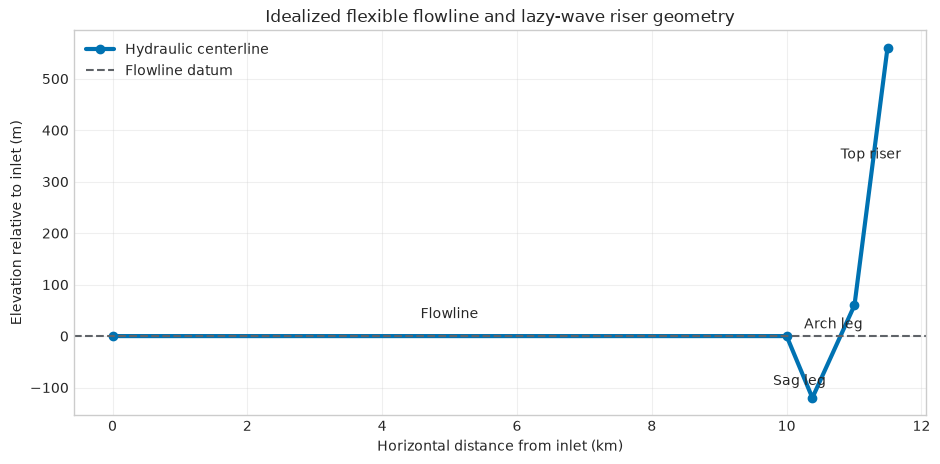

In [14]:
fig, ax = plt.subplots(figsize=(11.0, 5.0))
horizontal_positions_m = [0.0]
elevations_m = [0.0]

for row in LEG_SPECS.itertuples():
    horizontal_length_m = math.sqrt(
        row.length_m * row.length_m
        - row.elevation_change_m * row.elevation_change_m
    )
    horizontal_positions_m.append(
        horizontal_positions_m[-1] + horizontal_length_m
    )
    elevations_m.append(
        elevations_m[-1] + row.elevation_change_m
    )

ax.plot(
    np.asarray(horizontal_positions_m) / 1000.0,
    elevations_m,
    marker="o",
    linewidth=3.0,
    color=COLORS["blue"],
    label="Hydraulic centerline",
)
label_offsets_m = {
    "Flowline": 35.0,
    "Sag leg": -35.0,
    "Arch leg": 45.0,
    "Top riser": 35.0,
}

for index, row in enumerate(LEG_SPECS.itertuples()):
    midpoint_x = (
        horizontal_positions_m[index]
        + horizontal_positions_m[index + 1]
    ) / 2000.0
    midpoint_z = (
        elevations_m[index] + elevations_m[index + 1]
    ) / 2.0
    ax.text(
        midpoint_x,
        midpoint_z + label_offsets_m[row.leg],
        row.leg,
        ha="center",
        fontsize=10,
    )

ax.axhline(
    0.0,
    color=COLORS["grey"],
    linestyle="--",
    linewidth=1.5,
    label="Flowline datum",
)
ax.set_xlabel("Horizontal distance from inlet (km)")
ax.set_ylabel("Elevation relative to inlet (m)")
ax.set_title("Idealized flexible flowline and lazy-wave riser geometry")
ax.legend(loc="upper left")
ax.grid(alpha=0.3)
plt.show()

**Figure interpretation.** The connected-leg representation retains the hydrostatic
direction of the sag, arch, and riser. It is a hydraulic centerline model, not a
catenary, bending-stiffness, or structural equilibrium calculation.

In [15]:
def run_lazy_wave_system(
    diameter_m,
    flow_msm3_day,
    specified_u_w_m2_k=4.0,
):
    current_stream = create_wellstream(
        flow_msm3_day=flow_msm3_day,
        name=(
            f"lazy-wave feed {diameter_m:.2f} m "
            f"{flow_msm3_day:.1f} MSm3/day"
        ),
    )
    pipelines = []
    segment_records = []

    for row in LEG_SPECS.itertuples():
        increments = max(
            10,
            round(row.length_m / 100.0),
        )
        pipeline = configure_pipe(
            name=(
                f"{row.leg} {diameter_m:.2f} m "
                f"{flow_msm3_day:.1f} MSm3/day"
            ),
            inlet_stream=current_stream,
            length_m=row.length_m,
            diameter_m=diameter_m,
            elevation_m=row.elevation_change_m,
            increments=increments,
            thermal_mode="specified",
            specified_u_w_m2_k=specified_u_w_m2_k,
        )
        holdup_profile = np.asarray(
            pipeline.getLiquidHoldupProfile(),
            dtype=float,
        )
        segment_records.append(
            {
                "leg": row.leg,
                "inlet_pressure_bara": (
                    current_stream.getPressure("bara")
                ),
                "outlet_pressure_bara": (
                    pipeline.getOutStream().getPressure("bara")
                ),
                "pressure_drop_bar": pipeline.getPressureDrop(),
                "outlet_temperature_C": (
                    pipeline.getOutStream().getTemperature("C")
                ),
                "mean_liquid_holdup": holdup_profile.mean(),
                "mixture_velocity_m_s": (
                    pipeline.getMixtureVelocity()
                ),
                "allowable_velocity_m_s": (
                    pipeline.getMaxAllowableVelocity()
                ),
                "velocity_method": (
                    pipeline.getMaxVelocityMethod()
                ),
                "flow_regime": pipeline.getFlowRegime(),
            }
        )
        pipelines.append(pipeline)
        current_stream = pipeline.getOutStream()

    return {
        "pipelines": pipelines,
        "segments": pd.DataFrame(segment_records),
        "outlet": current_stream,
        "diameter_m": diameter_m,
        "flow_msm3_day": flow_msm3_day,
    }

In [16]:
base_lazy_wave = run_lazy_wave_system(
    diameter_m=0.30,
    flow_msm3_day=3.0,
)
base_segment_table = base_lazy_wave["segments"]
display(base_segment_table.round(4))

total_pressure_drop_bar = (
    ORIGINAL_PRESSURE_BARA
    - base_lazy_wave["outlet"].getPressure("bara")
)
summed_segment_drop_bar = (
    base_segment_table["pressure_drop_bar"].sum()
)

print(
    "Total flowline and riser pressure drop: "
    f"{total_pressure_drop_bar:.6f} bar"
)
print(
    "Sum of segment pressure drops: "
    f"{summed_segment_drop_bar:.6f} bar"
)

Total flowline and riser pressure drop: 16.926512 bar
Sum of segment pressure drops: 16.926512 bar


,leg,inlet_pressure_bara,outlet_pressure_bara,pressure_drop_bar,outlet_temperature_C,mean_liquid_holdup,mixture_velocity_m_s,allowable_velocity_m_s,velocity_method,flow_regime
0,Flowline,100.0000,94.2514,5.7486,37.1080,0.2203,4.5259,7.2747,"(A, P, I, _, R, P, _, 1, 4, E)","(I, N, T, E, R, M, I, T, T, E, N, T)"
1,Sag leg,94.2514,96.2405,-1.9891,37.3411,0.2190,4.4318,7.2579,"(A, P, I, _, R, P, _, 1, 4, E)","(I, N, T, E, R, M, I, T, T, E, N, T)"
2,Arch leg,96.2405,92.5119,3.7285,35.5869,0.2216,4.5808,7.2926,"(A, P, I, _, R, P, _, 1, 4, E)","(I, N, T, E, R, M, I, T, T, E, N, T)"
3,Top riser,92.5119,83.0735,9.4384,31.9407,0.2135,5.0443,7.4982,"(A, P, I, _, R, P, _, 1, 4, E)","(I, N, T, E, R, M, I, T, T, E, N, T)"


In [17]:
def stitch_profiles(pipelines):
    records = []
    cumulative_distance_m = 0.0
    cumulative_elevation_m = 0.0

    for leg_index, (pipeline, row) in enumerate(
        zip(pipelines, LEG_SPECS.itertuples())
    ):
        pressure = np.asarray(
            pipeline.getPressureProfile(),
            dtype=float,
        )
        temperature_c = np.asarray(
            pipeline.getTemperatureProfile(),
            dtype=float,
        ) - 273.15
        holdup = np.asarray(
            pipeline.getLiquidHoldupProfile(),
            dtype=float,
        )
        gas_velocity = np.asarray(
            list(
                pipeline.getGasSuperficialVelocityProfile()
            ),
            dtype=float,
        )
        liquid_velocity = np.asarray(
            list(
                pipeline.getLiquidSuperficialVelocityProfile()
            ),
            dtype=float,
        )
        local_distance_m = np.asarray(
            list(pipeline.getLengthProfile()),
            dtype=float,
        )
        local_elevation_m = (
            row.elevation_change_m
            * local_distance_m
            / row.length_m
        )

        start_index = 0 if leg_index == 0 else 1

        for point_index in range(start_index, len(pressure)):
            records.append(
                {
                    "leg": row.leg,
                    "distance_m": (
                        cumulative_distance_m
                        + local_distance_m[point_index]
                    ),
                    "elevation_m": (
                        cumulative_elevation_m
                        + local_elevation_m[point_index]
                    ),
                    "pressure_bara": pressure[point_index],
                    "temperature_C": (
                        temperature_c[point_index]
                    ),
                    "liquid_holdup": holdup[point_index],
                    "gas_superficial_velocity_m_s": (
                        gas_velocity[point_index]
                    ),
                    "liquid_superficial_velocity_m_s": (
                        liquid_velocity[point_index]
                    ),
                }
            )

        cumulative_distance_m += row.length_m
        cumulative_elevation_m += row.elevation_change_m

    return pd.DataFrame(records)


base_profile = stitch_profiles(base_lazy_wave["pipelines"])
display(base_profile.iloc[::20].round(4))

,leg,distance_m,elevation_m,pressure_bara,temperature_C,liquid_holdup,gas_superficial_velocity_m_s,liquid_superficial_velocity_m_s
0,Flowline,0.0,0.0,100.0000,50.1500,0.2195,4.1428,0.3884
20,Flowline,2000.0,0.0,98.8513,47.2330,0.2200,4.1342,0.3894
40,Flowline,4000.0,0.0,97.7028,44.4756,0.2203,4.1290,0.3902
60,Flowline,6000.0,0.0,96.5539,41.8728,0.2205,4.1274,0.3907
80,Flowline,8000.0,0.0,95.4037,39.4190,0.2205,4.1293,0.3910
100,Flowline,10000.0,0.0,94.2514,37.1080,0.2204,4.1347,0.3912
120,Arch leg,11050.0,60.0,92.5119,35.5869,0.2192,4.1903,0.3905


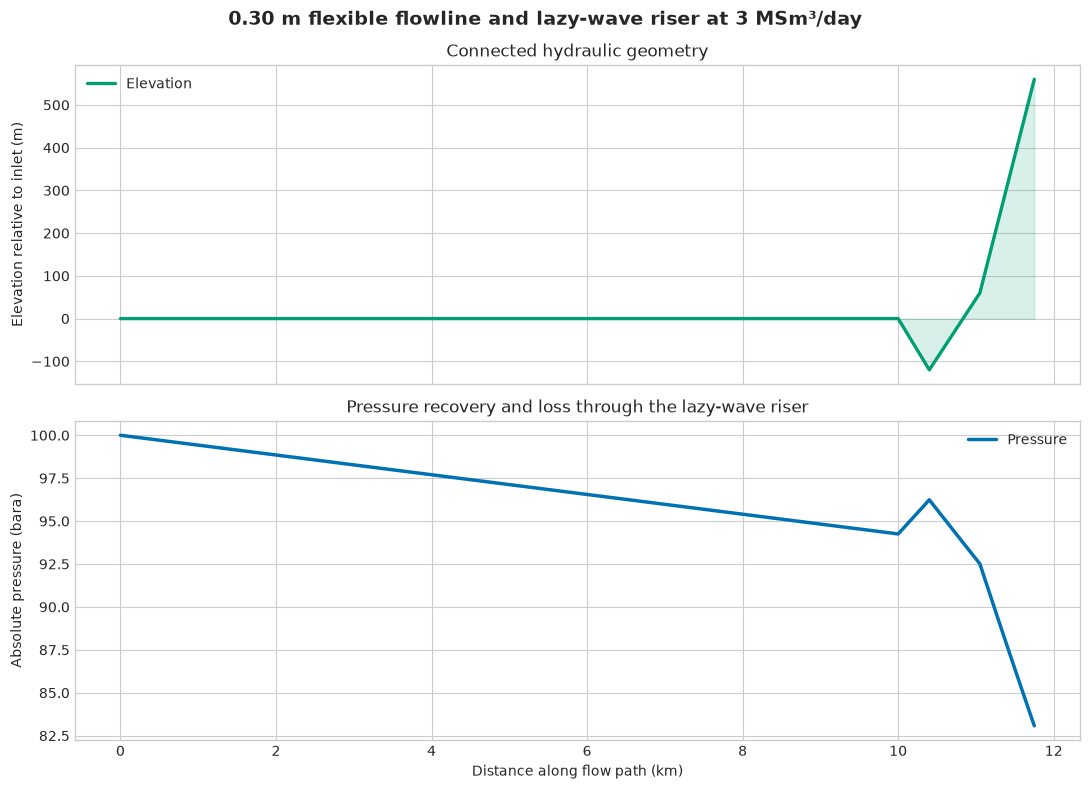

In [18]:
fig, axes = plt.subplots(2, 1, figsize=(11.0, 8.0), sharex=True)
distance_km = base_profile["distance_m"] / 1000.0

axes[0].plot(
    distance_km,
    base_profile["elevation_m"],
    color=COLORS["green"],
    linewidth=2.4,
    label="Elevation",
)
axes[0].fill_between(
    distance_km,
    0.0,
    base_profile["elevation_m"],
    color=COLORS["green"],
    alpha=0.15,
)
axes[0].set_ylabel("Elevation relative to inlet (m)")
axes[0].set_title("Connected hydraulic geometry")
axes[0].legend(loc="best")

axes[1].plot(
    distance_km,
    base_profile["pressure_bara"],
    color=COLORS["blue"],
    linewidth=2.5,
    label="Pressure",
)
axes[1].set_xlabel("Distance along flow path (km)")
axes[1].set_ylabel("Absolute pressure (bara)")
axes[1].set_title("Pressure recovery and loss through the lazy-wave riser")
axes[1].legend(loc="best")

fig.suptitle(
    "0.30 m flexible flowline and lazy-wave riser at 3 MSm³/day",
    fontsize=14,
    weight="bold",
)
fig.tight_layout()
plt.show()

**Figure interpretation.** Pressure falls through the seabed flowline, recovers through
the descending sag leg, then falls through the arch and 500 m topside rise. The sign of
each segment pressure drop is physically consistent with its elevation direction.

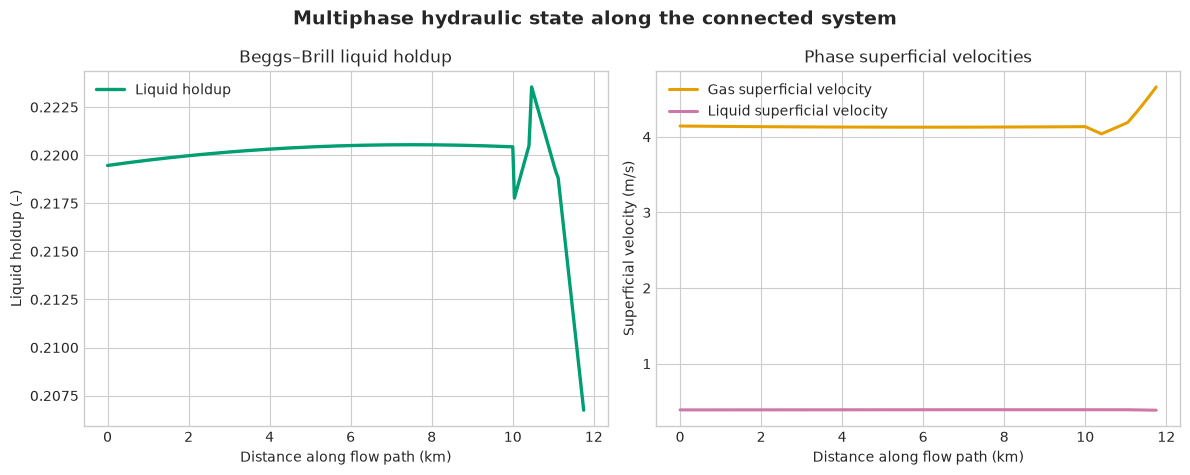

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.8))
distance_km = base_profile["distance_m"] / 1000.0

axes[0].plot(
    distance_km,
    base_profile["liquid_holdup"],
    color=COLORS["green"],
    linewidth=2.4,
    label="Liquid holdup",
)
axes[0].set_xlabel("Distance along flow path (km)")
axes[0].set_ylabel("Liquid holdup (–)")
axes[0].set_title("Beggs–Brill liquid holdup")
axes[0].legend(loc="best")

axes[1].plot(
    distance_km,
    base_profile["gas_superficial_velocity_m_s"],
    color=COLORS["orange"],
    linewidth=2.2,
    label="Gas superficial velocity",
)
axes[1].plot(
    distance_km,
    base_profile["liquid_superficial_velocity_m_s"],
    color=COLORS["purple"],
    linewidth=2.2,
    label="Liquid superficial velocity",
)
axes[1].set_xlabel("Distance along flow path (km)")
axes[1].set_ylabel("Superficial velocity (m/s)")
axes[1].set_title("Phase superficial velocities")
axes[1].legend(loc="best")

fig.suptitle(
    "Multiphase hydraulic state along the connected system",
    fontsize=14,
    weight="bold",
)
fig.tight_layout()
plt.show()

**Figure interpretation.** Holdup remains bounded between zero and one. Gas velocity
increases as pressure falls and gas expands. The predicted `INTERMITTENT` regime is a
steady Beggs–Brill classification; it does not calculate individual slug lengths or
arrival frequencies.

## 8. Velocity and erosion screening

The current pipe class exposes mixture velocity and its API RP 14E screening result.
This is a preliminary erosion indicator, not proof of flexible-liner, carcass, or
fitting integrity. Sand, droplets, corrosion, bend amplification, fatigue, and vendor
limits still require dedicated review.

In [20]:
velocity_table = base_segment_table[
    [
        "leg",
        "mixture_velocity_m_s",
        "allowable_velocity_m_s",
        "velocity_method",
    ]
].copy()
velocity_table["velocity_margin_m_s"] = (
    velocity_table["allowable_velocity_m_s"]
    - velocity_table["mixture_velocity_m_s"]
)
display(velocity_table.round(4))

,leg,mixture_velocity_m_s,allowable_velocity_m_s,velocity_method,velocity_margin_m_s
0,Flowline,4.5259,7.2747,"(A, P, I, _, R, P, _, 1, 4, E)",2.7489
1,Sag leg,4.4318,7.2579,"(A, P, I, _, R, P, _, 1, 4, E)",2.8260
2,Arch leg,4.5808,7.2926,"(A, P, I, _, R, P, _, 1, 4, E)",2.7118
3,Top riser,5.0443,7.4982,"(A, P, I, _, R, P, _, 1, 4, E)",2.4539


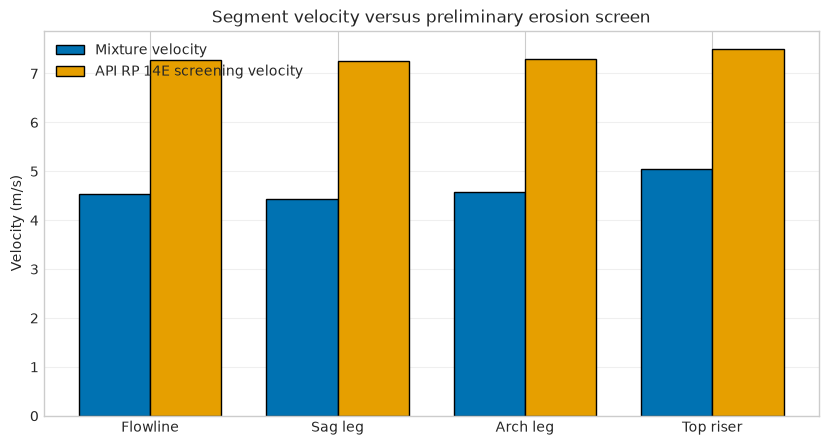

In [21]:
x_positions = np.arange(len(velocity_table))
bar_width = 0.38
fig, ax = plt.subplots(figsize=(10.0, 5.0))
ax.bar(
    x_positions - bar_width / 2.0,
    velocity_table["mixture_velocity_m_s"],
    width=bar_width,
    color=COLORS["blue"],
    edgecolor="black",
    label="Mixture velocity",
)
ax.bar(
    x_positions + bar_width / 2.0,
    velocity_table["allowable_velocity_m_s"],
    width=bar_width,
    color=COLORS["orange"],
    edgecolor="black",
    label="API RP 14E screening velocity",
)
ax.set_xticks(x_positions)
ax.set_xticklabels(velocity_table["leg"])
ax.set_ylabel("Velocity (m/s)")
ax.set_title("Segment velocity versus preliminary erosion screen")
ax.legend(loc="best")
ax.grid(axis="y", alpha=0.3)
plt.show()

**Figure interpretation.** The 0.30 m, 3 MSm³/day base case stays below the screening
velocity in every leg. The smallest margin occurs near the low-pressure riser outlet,
where volumetric gas flow is greatest.

## 9. Diameter and throughput sensitivity

Nine independent systems combine internal diameters of 0.25, 0.30, and 0.35 m with flows
of 2, 3, and 4 MSm³/day. Every case is rebuilt from a fresh stream, avoiding mutable-state
carryover. Feasibility requires at least 75 bara outlet pressure and nonnegative velocity
margin in all four legs.

In [22]:
scenario_records = []

for diameter_m in (0.25, 0.30, 0.35):
    for flow_msm3_day in (2.0, 3.0, 4.0):
        scenario = run_lazy_wave_system(
            diameter_m=diameter_m,
            flow_msm3_day=flow_msm3_day,
        )
        segments = scenario["segments"]
        outlet_pressure_bara = (
            scenario["outlet"].getPressure("bara")
        )
        maximum_velocity_m_s = (
            segments["mixture_velocity_m_s"].max()
        )
        minimum_velocity_margin_m_s = (
            (
                segments["allowable_velocity_m_s"]
                - segments["mixture_velocity_m_s"]
            ).min()
        )
        scenario_records.append(
            {
                "diameter_m": diameter_m,
                "flow_MSm3_day": flow_msm3_day,
                "outlet_pressure_bara": outlet_pressure_bara,
                "outlet_temperature_C": (
                    scenario["outlet"].getTemperature("C")
                ),
                "maximum_velocity_m_s": maximum_velocity_m_s,
                "minimum_velocity_margin_m_s": (
                    minimum_velocity_margin_m_s
                ),
                "pressure_ok": outlet_pressure_bara >= 75.0,
                "velocity_ok": minimum_velocity_margin_m_s >= 0.0,
            }
        )

scenario_table = pd.DataFrame(scenario_records)
scenario_table["feasible"] = (
    scenario_table["pressure_ok"]
    & scenario_table["velocity_ok"]
)
display(scenario_table.round(4))

,diameter_m,flow_MSm3_day,outlet_pressure_bara,outlet_temperature_C,maximum_velocity_m_s,minimum_velocity_margin_m_s,pressure_ok,velocity_ok,feasible
0,0.25,2.0,82.0738,28.8679,4.8285,2.6559,True,True,True
1,0.25,3.0,72.7288,34.4457,8.4811,-0.5461,False,False,False
2,0.25,4.0,56.8058,39.0169,15.0269,-6.2728,False,False,False
3,0.30,2.0,86.0978,26.0508,3.1370,4.1048,True,True,True
4,0.30,3.0,83.0735,31.9407,5.0443,2.4539,True,True,True
5,0.30,4.0,78.1899,35.4294,7.3031,0.4368,True,True,True
6,0.35,2.0,86.3420,23.1694,2.2615,4.5562,True,True,True
7,0.35,3.0,86.2820,29.8282,3.5194,3.8003,True,True,True
8,0.35,4.0,84.3713,33.5780,4.9007,2.5753,True,True,True


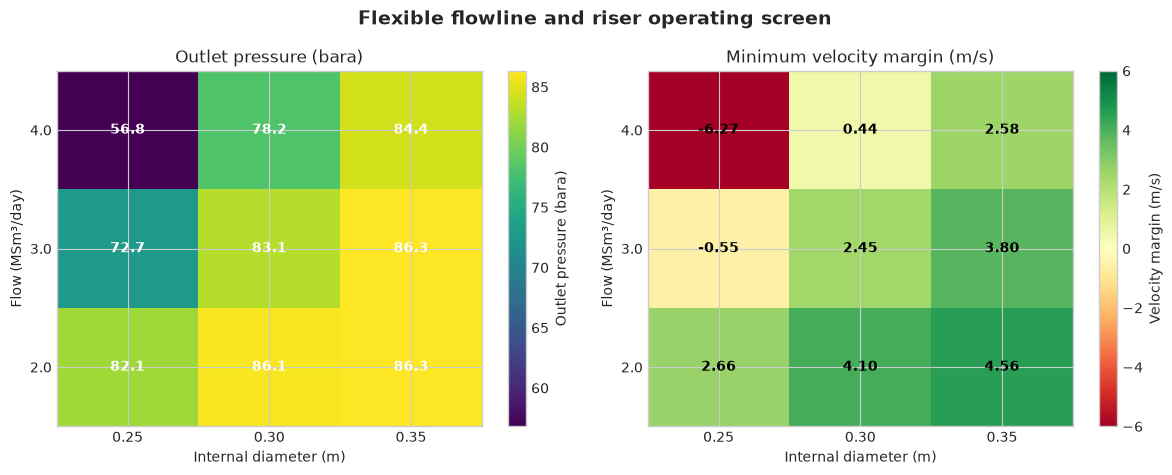

In [23]:
pressure_grid = scenario_table.pivot(
    index="flow_MSm3_day",
    columns="diameter_m",
    values="outlet_pressure_bara",
)
margin_grid = scenario_table.pivot(
    index="flow_MSm3_day",
    columns="diameter_m",
    values="minimum_velocity_margin_m_s",
)

fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.8))
pressure_image = axes[0].imshow(
    pressure_grid.values,
    cmap="viridis",
    aspect="auto",
    origin="lower",
)
margin_image = axes[1].imshow(
    margin_grid.values,
    cmap="RdYlGn",
    aspect="auto",
    origin="lower",
    vmin=-6.0,
    vmax=6.0,
)

for row_index in range(pressure_grid.shape[0]):
    for column_index in range(pressure_grid.shape[1]):
        axes[0].text(
            column_index,
            row_index,
            f"{pressure_grid.values[row_index, column_index]:.1f}",
            ha="center",
            va="center",
            color="white",
            weight="bold",
        )
        axes[1].text(
            column_index,
            row_index,
            f"{margin_grid.values[row_index, column_index]:.2f}",
            ha="center",
            va="center",
            color="black",
            weight="bold",
        )

for ax in axes:
    ax.set_xticks(range(len(pressure_grid.columns)))
    ax.set_xticklabels(
        [f"{value:.2f}" for value in pressure_grid.columns]
    )
    ax.set_yticks(range(len(pressure_grid.index)))
    ax.set_yticklabels(
        [f"{value:.1f}" for value in pressure_grid.index]
    )
    ax.set_xlabel("Internal diameter (m)")
    ax.set_ylabel("Flow (MSm³/day)")

axes[0].set_title("Outlet pressure (bara)")
axes[1].set_title("Minimum velocity margin (m/s)")
fig.colorbar(
    pressure_image,
    ax=axes[0],
    label="Outlet pressure (bara)",
)
fig.colorbar(
    margin_image,
    ax=axes[1],
    label="Velocity margin (m/s)",
)
fig.suptitle(
    "Flexible flowline and riser operating screen",
    fontsize=14,
    weight="bold",
)
fig.tight_layout()
plt.show()

**Figure interpretation.** The 0.25 m bore loses velocity margin at 3 and 4 MSm³/day.
Larger bores retain both pressure and velocity margin. The screen reveals a trade-off,
not an economic optimum: minimum bend radius, weight, installation vessel, fatigue, and
procurement constraints are absent.

## 10. Select a practical hydraulic candidate

The selection rule chooses the smallest feasible bore at the target 4 MSm³/day. This
demonstrates how to reuse the workflow for an engineering decision while keeping the
assumptions and acceptance criteria visible.

In [24]:
TARGET_FLOW_MSM3_DAY = 4.0
target_cases = scenario_table.loc[
    scenario_table["flow_MSm3_day"] == TARGET_FLOW_MSM3_DAY
].sort_values("diameter_m")
feasible_target_cases = target_cases.loc[
    target_cases["feasible"]
]
selected_case = feasible_target_cases.iloc[0]

display(target_cases.round(4))
print(
    "Selected internal diameter at "
    f"{TARGET_FLOW_MSM3_DAY:.1f} MSm³/day: "
    f"{selected_case['diameter_m']:.2f} m"
)
print(
    "Selected outlet pressure: "
    f"{selected_case['outlet_pressure_bara']:.6f} bara"
)
print(
    "Selected minimum velocity margin: "
    f"{selected_case['minimum_velocity_margin_m_s']:.6f} m/s"
)

Selected internal diameter at 4.0 MSm³/day: 0.30 m
Selected outlet pressure: 78.189863 bara
Selected minimum velocity margin: 0.436830 m/s


,diameter_m,flow_MSm3_day,outlet_pressure_bara,outlet_temperature_C,maximum_velocity_m_s,minimum_velocity_margin_m_s,pressure_ok,velocity_ok,feasible
2,0.25,4.0,56.8058,39.0169,15.0269,-6.2728,False,False,False
5,0.30,4.0,78.1899,35.4294,7.3031,0.4368,True,True,True
8,0.35,4.0,84.3713,33.5780,4.9007,2.5753,True,True,True


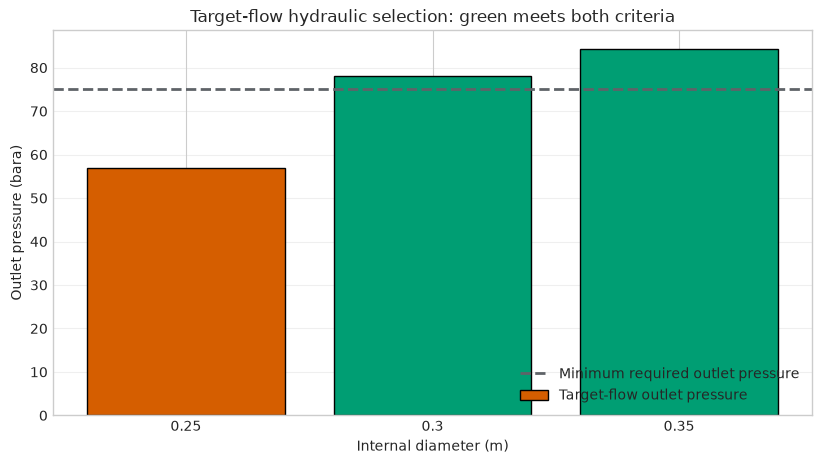

In [25]:
fig, ax = plt.subplots(figsize=(9.8, 5.0))
bar_colors = [
    COLORS["green"] if feasible else COLORS["red"]
    for feasible in target_cases["feasible"]
]
ax.bar(
    target_cases["diameter_m"].astype(str),
    target_cases["outlet_pressure_bara"],
    color=bar_colors,
    edgecolor="black",
    label="Target-flow outlet pressure",
)
ax.axhline(
    75.0,
    color=COLORS["grey"],
    linestyle="--",
    linewidth=2.0,
    label="Minimum required outlet pressure",
)
ax.set_xlabel("Internal diameter (m)")
ax.set_ylabel("Outlet pressure (bara)")
ax.set_title(
    "Target-flow hydraulic selection: green meets both criteria"
)
ax.legend(loc="lower right")
ax.grid(axis="y", alpha=0.3)
plt.show()

**Figure interpretation.** At 4 MSm³/day, 0.30 m is the smallest tested bore that meets
both the 75 bara outlet-pressure criterion and the API RP 14E velocity screen. The
0.25 m case is red because velocity fails even though the calculation converges.

## 11. Verification and engineering checks

The assertions verify JSON-independent numerical behavior: composition closure, phases,
pressure-profile closure, bounded holdup, positive velocities, thermal ordering,
connected-leg continuity, pressure recovery, total-drop closure, velocity margins,
expected sensitivity trends, and final design criteria.

In [26]:
original_profile_drop_bar = (
    original_pressure_bar[0] - original_pressure_bar[-1]
)
detailed_outlet_temperature_c = float(
    thermal_table.loc[
        thermal_table["case"] == "Detailed 50 mm insulation",
        "outlet_temperature_C",
    ].iloc[0]
)
specified_outlet_temperature_c = float(
    thermal_table.loc[
        thermal_table["case"] == "Specified U = 4 W/(m²·K)",
        "outlet_temperature_C",
    ].iloc[0]
)
adiabatic_outlet_temperature_c = float(
    thermal_table.loc[
        thermal_table["case"] == "Adiabatic",
        "outlet_temperature_C",
    ].iloc[0]
)

checks = {
    "NeqSim version recorded": bool(NEQSIM_VERSION),
    "Python version recorded": bool(PYTHON_VERSION),
    "Java version recorded": bool(JAVA_VERSION),
    "Composition sums to one": (
        abs(sum(COMPOSITION.values()) - 1.0) < 1.0e-12
    ),
    "Three feed phases present": (
        feed_system.getNumberOfPhases() == 3
    ),
    "Original outlet pressure positive": (
        original_pipeline.getOutStream().getPressure("bara") > 0.0
    ),
    "Original total pressure drop positive": (
        original_pipeline.getPressureDrop() > 0.0
    ),
    "Original pressure profile closes": (
        abs(
            original_profile_drop_bar
            - original_pipeline.getPressureDrop()
        )
        < 1.0e-8
    ),
    "Original pressures decrease monotonically": (
        np.diff(original_pressure_bar) < 0.0
    ).all(),
    "Original holdup bounded": (
        (original_holdup > 0.0).all()
        and (original_holdup < 1.0).all()
    ),
    "Original gas velocity positive": (
        original_gas_velocity_m_s > 0.0
    ).all(),
    "Original liquid velocity positive": (
        original_liquid_velocity_m_s > 0.0
    ).all(),
    "Detailed U is below specified U": (
        thermal_table.loc[
            thermal_table["case"] == "Detailed 50 mm insulation",
            "effective_U_W_m2_K",
        ].iloc[0]
        < 4.0
    ),
    "Adiabatic case is warmest": (
        adiabatic_outlet_temperature_c
        > detailed_outlet_temperature_c
    ),
    "Detailed insulation warmer than specified U": (
        detailed_outlet_temperature_c
        > specified_outlet_temperature_c
    ),
    "All base segment pressures positive": (
        base_segment_table["outlet_pressure_bara"] > 0.0
    ).all(),
    "All base holdups bounded": (
        (base_segment_table["mean_liquid_holdup"] > 0.0).all()
        and (
            base_segment_table["mean_liquid_holdup"] < 1.0
        ).all()
    ),
    "Sag leg recovers pressure": (
        base_segment_table.loc[
            base_segment_table["leg"] == "Sag leg",
            "pressure_drop_bar",
        ].iloc[0]
        < 0.0
    ),
    "Arch leg loses pressure": (
        base_segment_table.loc[
            base_segment_table["leg"] == "Arch leg",
            "pressure_drop_bar",
        ].iloc[0]
        > 0.0
    ),
    "Top riser loses pressure": (
        base_segment_table.loc[
            base_segment_table["leg"] == "Top riser",
            "pressure_drop_bar",
        ].iloc[0]
        > 0.0
    ),
    "Connected pressure-drop sum closes": (
        abs(total_pressure_drop_bar - summed_segment_drop_bar)
        < 1.0e-8
    ),
    "Base velocity screen passes": (
        velocity_table["velocity_margin_m_s"] > 0.0
    ).all(),
    "Every scenario finite": np.isfinite(
        scenario_table.select_dtypes(include="number")
    ).all().all(),
    "Small bore fails at maximum rate": (
        not bool(
            scenario_table.loc[
                (scenario_table["diameter_m"] == 0.25)
                & (
                    scenario_table["flow_MSm3_day"]
                    == TARGET_FLOW_MSM3_DAY
                ),
                "velocity_ok",
            ].iloc[0]
        )
    ),
    "Larger bore raises target outlet pressure": (
        target_cases["outlet_pressure_bara"].is_monotonic_increasing
    ),
    "Feasible target case exists": (
        not feasible_target_cases.empty
    ),
    "Selected diameter is 0.30 m": (
        abs(selected_case["diameter_m"] - 0.30) < 1.0e-12
    ),
    "Selected outlet pressure meets criterion": (
        selected_case["outlet_pressure_bara"] >= 75.0
    ),
    "Selected velocity margin meets criterion": (
        selected_case["minimum_velocity_margin_m_s"] >= 0.0
    ),
}

failed_checks = [
    check_name
    for check_name, passed in checks.items()
    if not passed
]

assert not failed_checks, f"Failed checks: {failed_checks}"
print(f"All {len(checks)} engineering checks passed.")

All 29 engineering checks passed.


## 12. Troubleshooting

- **Duplicate equipment names:** use direct Java `Stream` and `PipeBeggsAndBrills`
  objects or a fresh process context instead of accumulating global wrapper state.
- **Negative outlet pressure or nonconvergence:** reduce rate, increase diameter, shorten
  increments, or verify that pressure units and elevation signs are correct.
- **Descending-leg pressure behaves incorrectly:** use negative outlet-minus-inlet
  elevation and a consistent angle.
- **Temperature profile has one point:** enable a nonadiabatic thermal mode before `run()`.
- **Unexpected holdup:** confirm the inlet flash has the intended phases and compare
  composition, rate, diameter, inclination, and model validity.
- **Velocity screen fails:** do not hide the failure by changing the plotted scale; revise
  bore, rate, routing, or the project-specific allowable-velocity basis.

## 13. Applicability and practical limitations

This notebook is suitable for education, API demonstrations, early hydraulic option
screening, and reproducible comparison of flowline/riser scenarios. Project design also
needs validated PVT, terrain, transient startup and shutdown, severe-slugging assessment,
hydrate and wax kinetics, sand erosion, corrosion, fittings, local losses, downstream
backpressure, availability, uncertainty, and operating envelopes.

Flexible-pipe structural design is explicitly outside the hydraulic model. Bore selection
must be reconciled with collapse, burst, armor utilization, fatigue, curvature, minimum
bend radius, end fitting, installation, annulus, permeability, and vendor qualification.

## 14. Summary

- The original three-phase 100 km Beggs–Brill example is preserved and numerically
  refreshed with internally consistent total pressure drop.
- Current NeqSim exposes complete pressure, temperature, holdup, velocity, density,
  regime, length, and elevation profiles.
- Specified and detailed heat-transfer modes quantify insulation effects.
- Connected straight legs reproduce pressure recovery in the sag and pressure loss in
  the arch and topside riser.
- API RP 14E provides a transparent preliminary velocity screen.
- A nine-case diameter/rate study selects 0.30 m as the smallest tested feasible bore at
  4 MSm³/day under the stated hydraulic criteria.

## 15. Further exercises

1. Replace the synthetic three-component fluid with a documented reservoir-fluid model.
2. Compare SRK and a water-capable CPA model while preserving the same overall feed.
3. Add local loss coefficients for bends, end fittings, and topside valves.
4. Vary seawater temperature, insulation thickness, and conductivity.
5. Add a low-rate turndown case and screen severe-slugging risk with a transient model.
6. Couple the selected hydraulic bore to a separate API 17J structural design workflow.
7. Replace the single velocity criterion with project erosion, sand, corrosion, and
   flexible-liner limits.

## 16. References

- NeqSim current source and API:
  [`PipeBeggsAndBrills`](https://github.com/equinor/neqsim/blob/master/src/main/java/neqsim/process/equipment/pipeline/PipeBeggsAndBrills.java)
- NeqSim Python package: [PyPI `neqsim`](https://pypi.org/project/neqsim/)
- Beggs, H. D. and Brill, J. P. (1973), “A Study of Two-Phase Flow in
  Inclined Pipes,” *Journal of Petroleum Technology*, SPE-4007-PA.
- API RP 14E, *Recommended Practice for Design and Installation of Offshore Production
  Platform Piping Systems*.
- API 17J and API 17B for unbonded flexible pipe specification and recommended practice.
- DNV-ST-F119, *Thermoplastic Composite Pipes*.
- Bratland, O., public multiphase-flow learning resources:
  [drbratland.com](http://www.drbratland.com/).